In [1]:
!pip install kaggle --quiet

In [2]:
!kaggle datasets download -d mathurinache/world-happiness-report --unzip -p /content/data/

Dataset URL: https://www.kaggle.com/datasets/mathurinache/world-happiness-report
License(s): CC0-1.0
100% 67.4k/67.4k [00:00<00:00, 48.5MB/s]



In [3]:
!kaggle datasets download -d unsdsn/world-happiness --unzip -p /content/data/


Dataset URL: https://www.kaggle.com/datasets/unsdsn/world-happiness
License(s): CC0-1.0
100% 36.8k/36.8k [00:00<00:00, 57.3MB/s]



In [4]:
import os
for f in sorted(os.listdir('/content/data/')):
    print(f)

2015.csv
2016.csv
2017.csv
2018.csv
2019.csv
2020.csv
2021.csv
2022.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
print("✅ All libraries imported!")

✅ All libraries imported!


In [6]:
dfs = []

for year in range(2015, 2023):
    filepath = f'/content/data/{year}.csv'
    if not os.path.exists(filepath):
        continue
    df = pd.read_csv(filepath)
    df['Year'] = year

    # Rename columns to standard names
    df.columns = df.columns.str.strip()
    rename_map = {
        'Country': 'Country', 'Country or region': 'Country',
        'Region': 'Region',
        'Happiness Score': 'Happiness_Score',
        'Happiness.Score': 'Happiness_Score',
        'Score': 'Happiness_Score',
        'Economy (GDP per Capita)': 'GDP',
        'Economy..GDP.per.Capita.': 'GDP',
        'GDP per capita': 'GDP',
        'Family': 'Social_Support',
        'Social support': 'Social_Support',
        'Health (Life Expectancy)': 'Health',
        'Health..Life.Expectancy.': 'Health',
        'Healthy life expectancy': 'Health',
        'Freedom to make life choices': 'Freedom',
        'Freedom': 'Freedom',
        'Trust (Government Corruption)': 'Corruption',
        'Trust..Government.Corruption.': 'Corruption',
        'Perceptions of corruption': 'Corruption',
        'Generosity': 'Generosity',
    }
    df = df.rename(columns=rename_map)

    keep = ['Country','Region','Happiness_Score','GDP',
            'Social_Support','Health','Freedom','Corruption','Generosity','Year']
    df = df[[c for c in keep if c in df.columns]]
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f"✅ Merged shape: {data.shape}")
print(f"   Years: {sorted(data['Year'].unique())}")
print(f"   Countries: {data['Country'].nunique()}")
data.head()

✅ Merged shape: (1231, 10)
   Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
   Countries: 195


,Country,Region,Happiness_Score,GDP,Social_Support,Health,Freedom,Corruption,Generosity,Year
0,Switzerland,Western Europe,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,Western Europe,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,Western Europe,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,Western Europe,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,North America,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


In [7]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

                 Missing Count  Missing %
Country                    302      24.53
Region                     916      74.41
Happiness_Score            449      36.47
GDP                        449      36.47
Social_Support             147      11.94
Health                     147      11.94
Freedom                    147      11.94
Corruption                 148      12.02
Generosity                 147      11.94
Year                         0       0.00


In [8]:
# Fill missing Region
data['Region'] = data['Region'].fillna('Unknown')

# Numeric columns
numeric_cols = ['Happiness_Score','GDP','Social_Support',
                'Health','Freedom','Corruption','Generosity']

# Fill nulls with yearly median
for col in numeric_cols:
    data[col] = data.groupby('Year')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Encode Region as numeric category
data['Region_Code'] = pd.Categorical(data['Region']).codes

print("✅ Nulls remaining:", data.isnull().sum().sum())
print(f"   Regions found: {data['Region'].nunique()}")
print(data['Region'].value_counts())

✅ Nulls remaining: 1935
   Regions found: 11
Region
Unknown                            916
Sub-Saharan Africa                  78
Central and Eastern Europe          58
Latin America and Caribbean         46
Western Europe                      42
Middle East and Northern Africa     39
Southeastern Asia                   18
Southern Asia                       14
Eastern Asia                        12
Australia and New Zealand            4
North America                        4
Name: count, dtype: int64


In [12]:
# Just count outliers per column for reporting, don't drop rows
data_clean = data.copy()

outlier_cols = ['Happiness_Score','GDP','Social_Support',
                'Health','Freedom','Corruption','Generosity']

outlier_report = {}
for col in outlier_cols:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (data_clean[col] < Q1 - 1.5*IQR) | (data_clean[col] > Q3 + 1.5*IQR)
    outlier_report[col] = mask.sum()
    data_clean[f'{col}_outlier'] = mask  # flag column

print("✅ Outlier counts per column (flagged, not dropped):")
for col, count in outlier_report.items():
    print(f"   {col}: {count} outliers")

print(f"\n   Final shape: {data_clean.shape}")
print(f"   All data retained: {len(data_clean)} rows")

✅ Outlier counts per column (flagged, not dropped):
   Happiness_Score: 0 outliers
   GDP: 0 outliers
   Social_Support: 8 outliers
   Health: 0 outliers
   Freedom: 0 outliers
   Corruption: 0 outliers
   Generosity: 33 outliers

   Final shape: (1231, 18)
   All data retained: 1231 rows


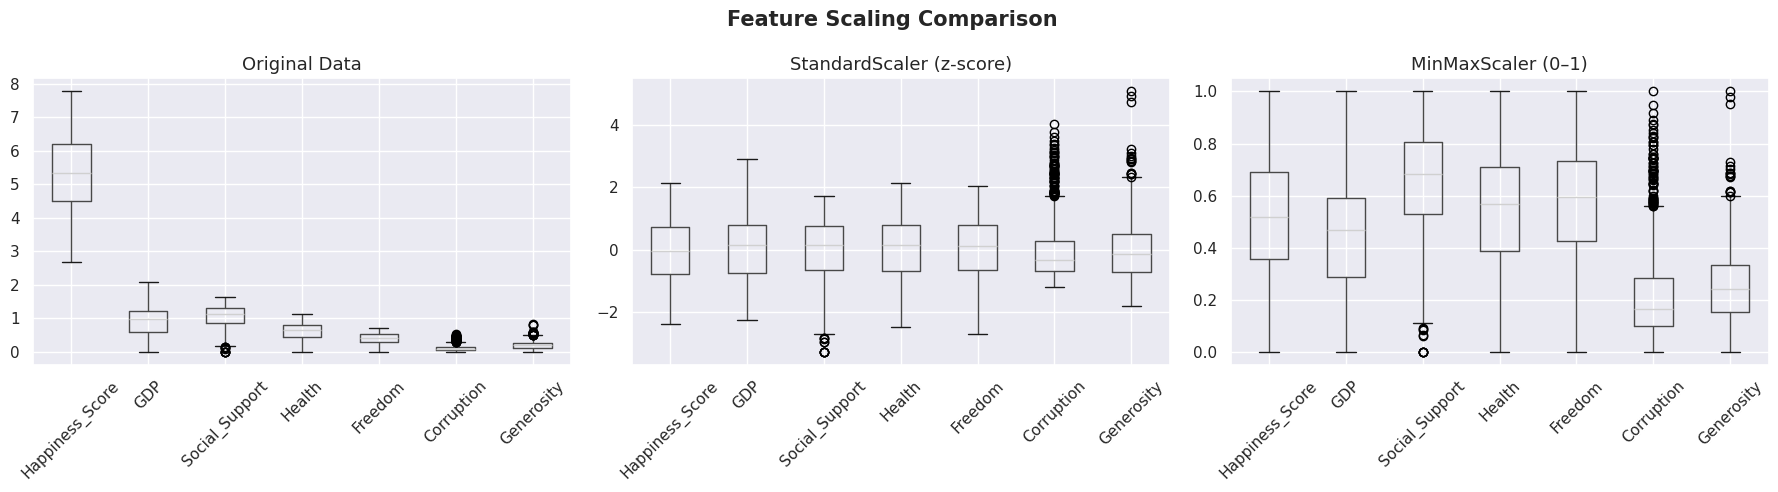

✅ Scaling comparison done!


In [13]:
numeric_cols = ['Happiness_Score','GDP','Social_Support',
                'Health','Freedom','Corruption','Generosity']

scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

sample = data_clean[numeric_cols].dropna()
std_scaled = pd.DataFrame(scaler_std.fit_transform(sample), columns=numeric_cols)
mm_scaled  = pd.DataFrame(scaler_mm.fit_transform(sample),  columns=numeric_cols)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample.boxplot(ax=axes[0])
axes[0].set_title('Original Data', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

std_scaled.boxplot(ax=axes[1])
axes[1].set_title('StandardScaler (z-score)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

mm_scaled.boxplot(ax=axes[2])
axes[2].set_title('MinMaxScaler (0–1)', fontsize=13)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Scaling Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Scaling comparison done!")

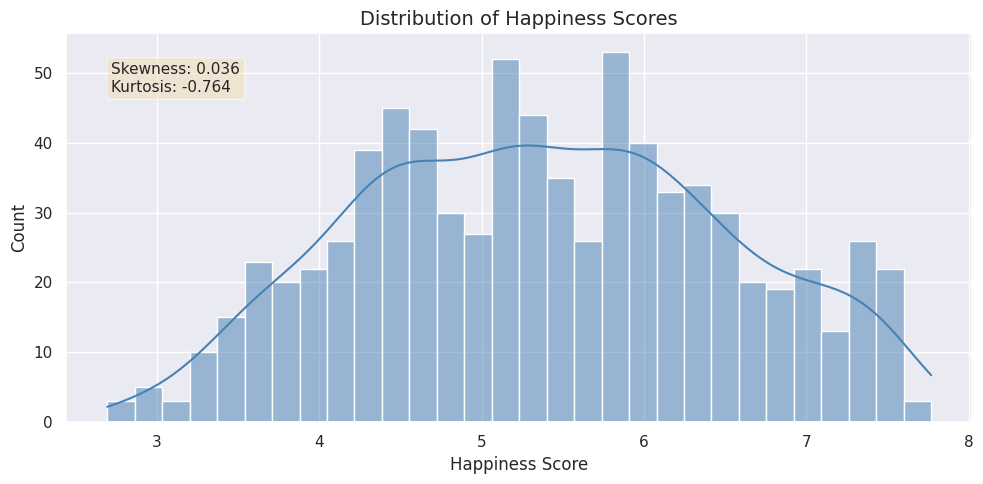

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(data_clean['Happiness_Score'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Happiness Scores', fontsize=14)
plt.xlabel('Happiness Score')
plt.ylabel('Count')
sk = skew(data_clean['Happiness_Score'].dropna())
ku = kurtosis(data_clean['Happiness_Score'].dropna())
plt.annotate(f'Skewness: {sk:.3f}\nKurtosis: {ku:.3f}',
             xy=(0.05, 0.85), xycoords='axes fraction', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

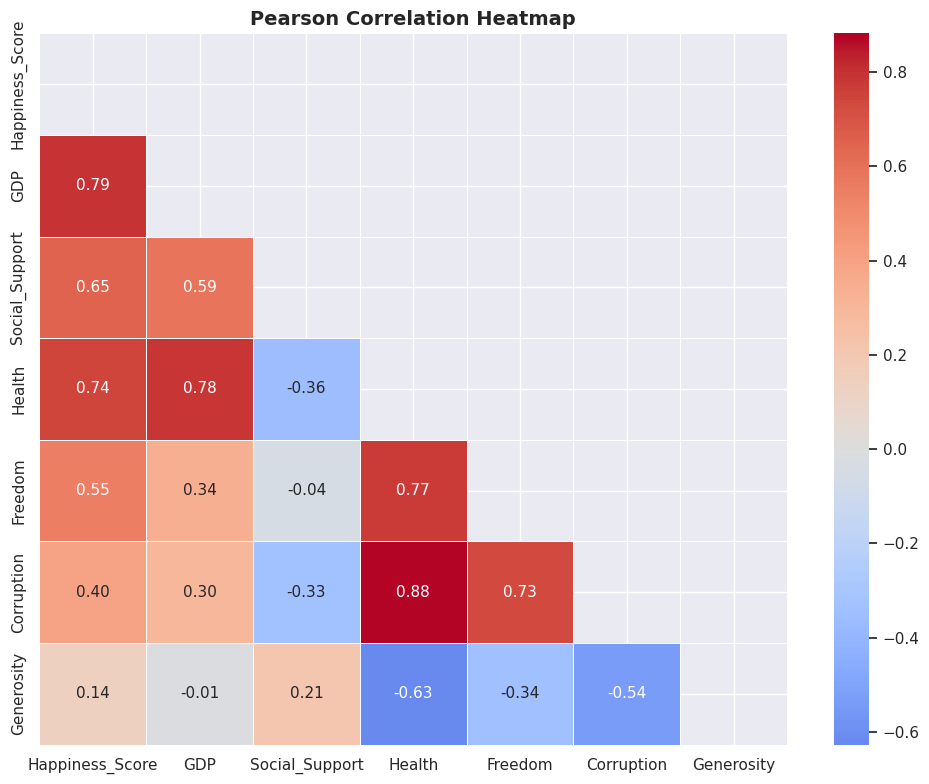

✅ Heatmap done!


In [15]:
plt.figure(figsize=(10,8))
corr = data_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 11})
plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Heatmap done!")

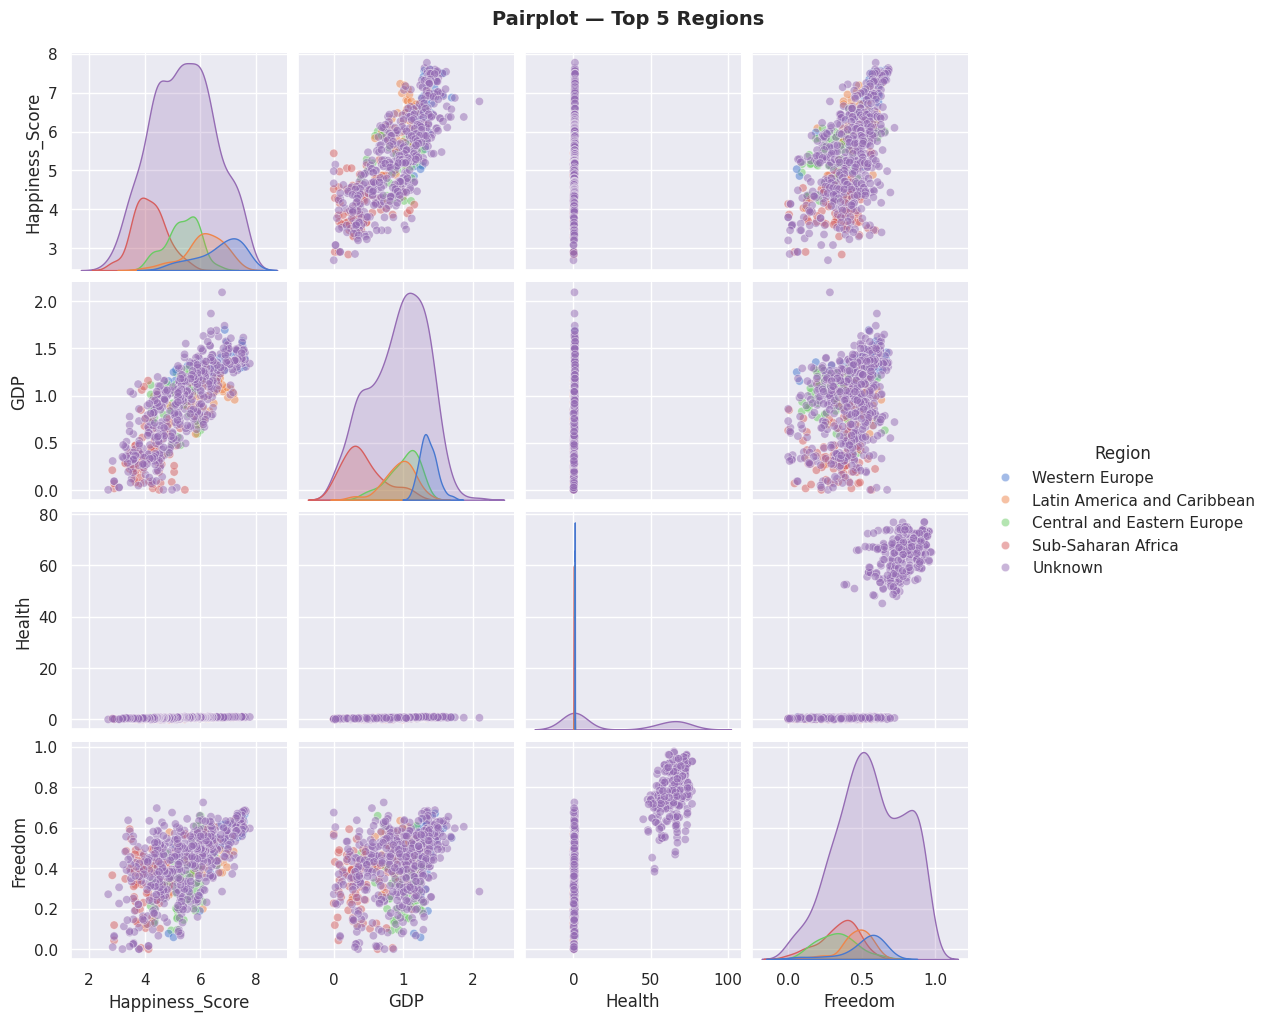

✅ Pairplot done!


In [16]:
top_regions = data_clean['Region'].value_counts().head(5).index
pair_df = data_clean[data_clean['Region'].isin(top_regions)]

sns.pairplot(pair_df[['Happiness_Score','GDP','Health','Freedom','Region']],
             hue='Region', diag_kind='kde',
             plot_kws={'alpha':0.5}, height=2.5)
plt.suptitle('Pairplot — Top 5 Regions', y=1.02, fontsize=14, fontweight='bold')
plt.show()
print("✅ Pairplot done!")

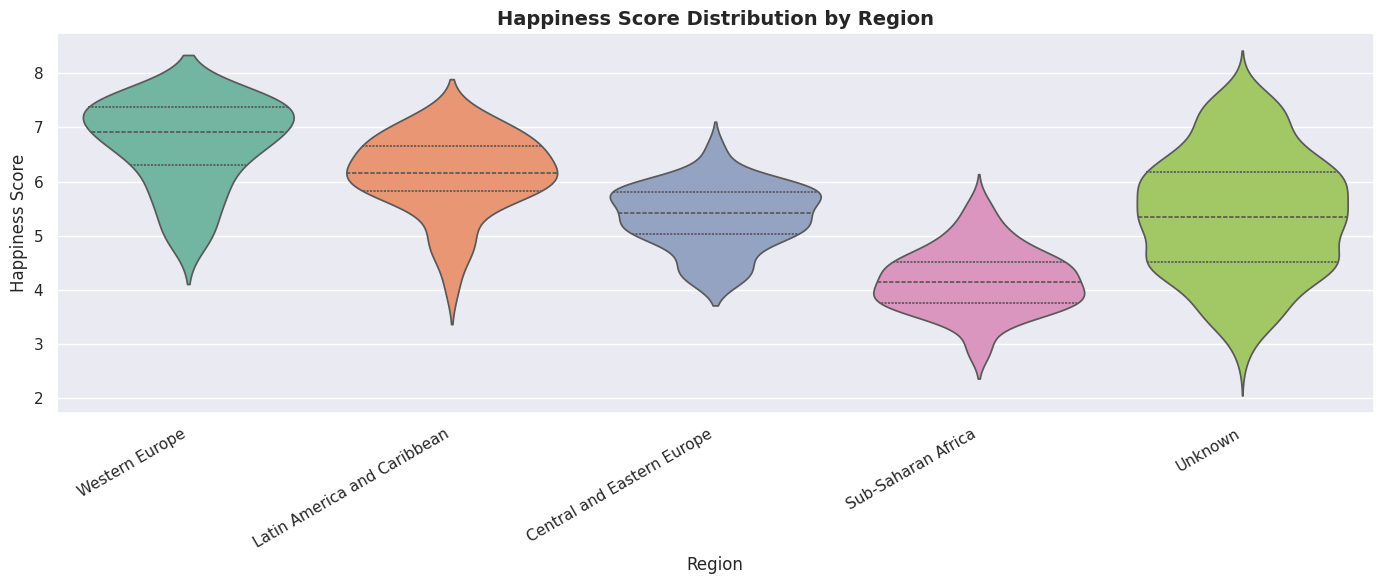

✅ Violin plot done!


In [17]:
plt.figure(figsize=(14,6))
top5 = data_clean[data_clean['Region'].isin(top_regions)]
sns.violinplot(data=top5, x='Region', y='Happiness_Score',
               palette='Set2', inner='quartile')
plt.xticks(rotation=30, ha='right')
plt.title('Happiness Score Distribution by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()
print("✅ Violin plot done!")

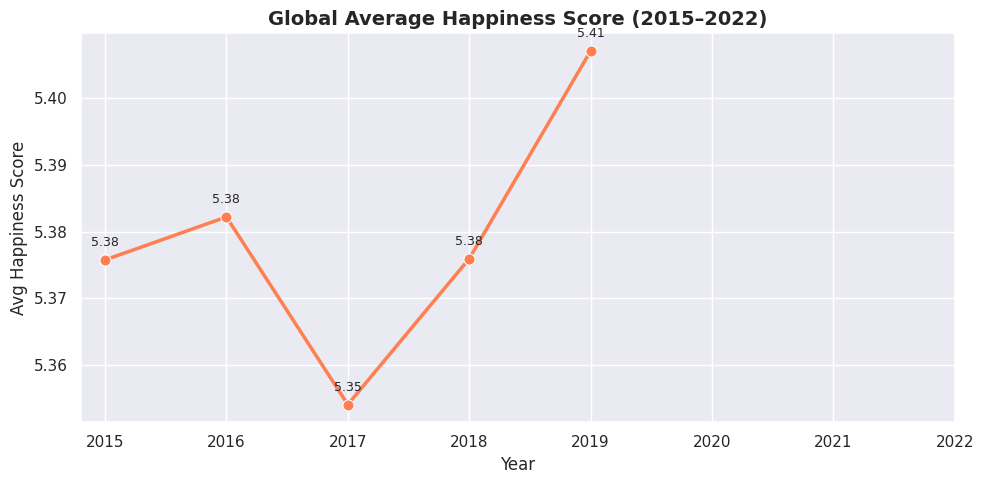

✅ Year trend done!


In [18]:
yearly = data_clean.groupby('Year')['Happiness_Score'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly, x='Year', y='Happiness_Score',
             marker='o', linewidth=2.5, color='coral', markersize=8)

for _, row in yearly.iterrows():
    plt.annotate(f"{row['Happiness_Score']:.2f}",
                 xy=(row['Year'], row['Happiness_Score']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9)

plt.title('Global Average Happiness Score (2015–2022)', fontsize=14, fontweight='bold')
plt.ylabel('Avg Happiness Score')
plt.xlabel('Year')
plt.xticks(yearly['Year'].astype(int))
plt.tight_layout()
plt.show()
print("✅ Year trend done!")

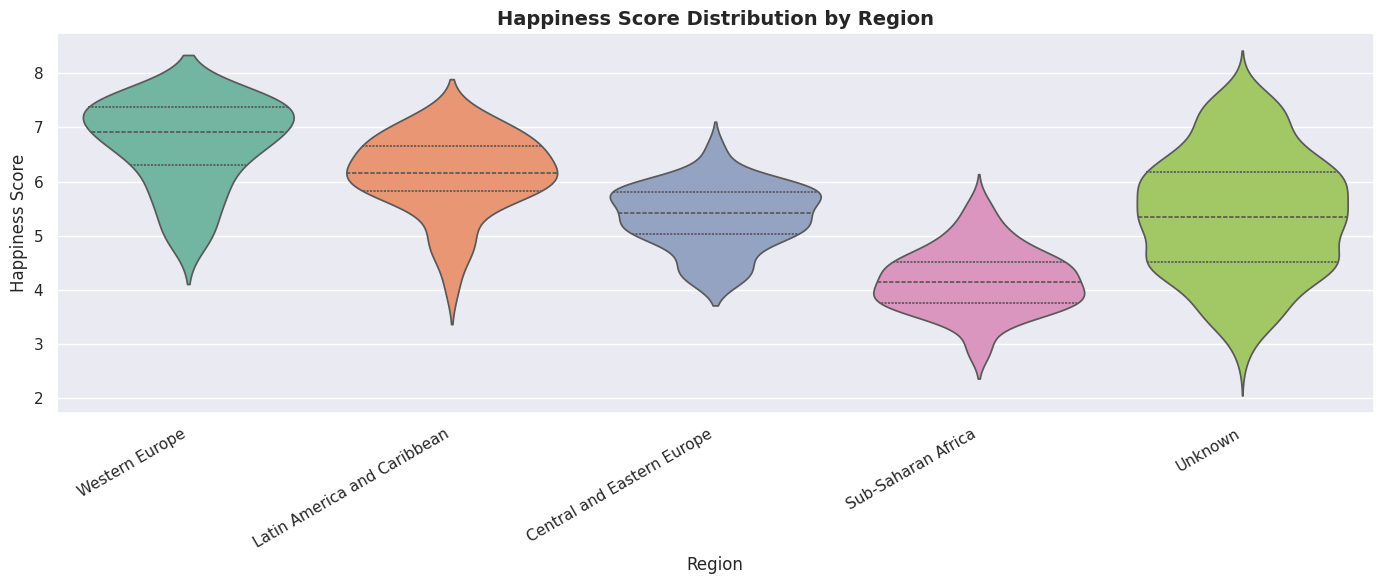

✅ Violin plot done!


In [19]:
plt.figure(figsize=(14,6))
top5 = data_clean[data_clean['Region'].isin(top_regions)]
sns.violinplot(data=top5, x='Region', y='Happiness_Score',
               palette='Set2', inner='quartile')
plt.xticks(rotation=30, ha='right')
plt.title('Happiness Score Distribution by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()
print("✅ Violin plot done!")

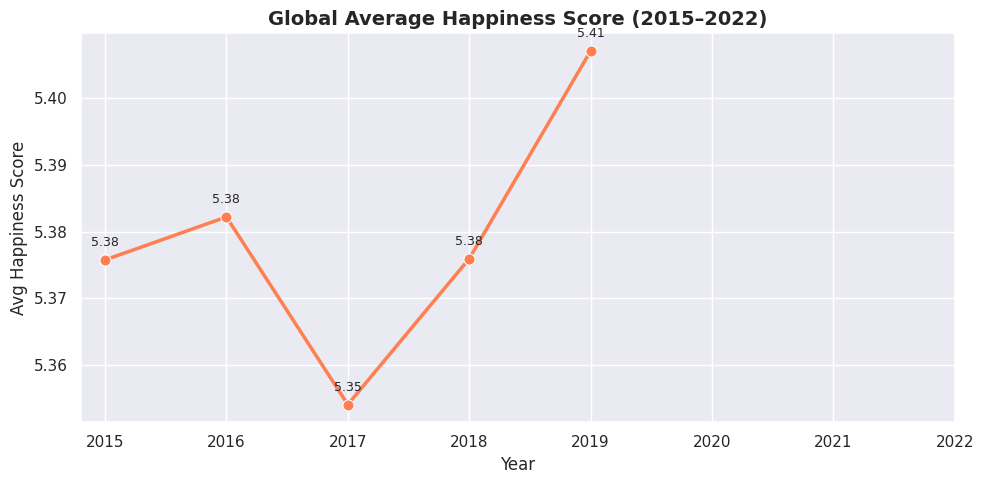

✅ Year trend done!


In [20]:
yearly = data_clean.groupby('Year')['Happiness_Score'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly, x='Year', y='Happiness_Score',
             marker='o', linewidth=2.5, color='coral', markersize=8)

for _, row in yearly.iterrows():
    plt.annotate(f"{row['Happiness_Score']:.2f}",
                 xy=(row['Year'], row['Happiness_Score']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9)

plt.title('Global Average Happiness Score (2015–2022)', fontsize=14, fontweight='bold')
plt.ylabel('Avg Happiness Score')
plt.xlabel('Year')
plt.xticks(yearly['Year'].astype(int))
plt.tight_layout()
plt.show()
print("✅ Year trend done!")

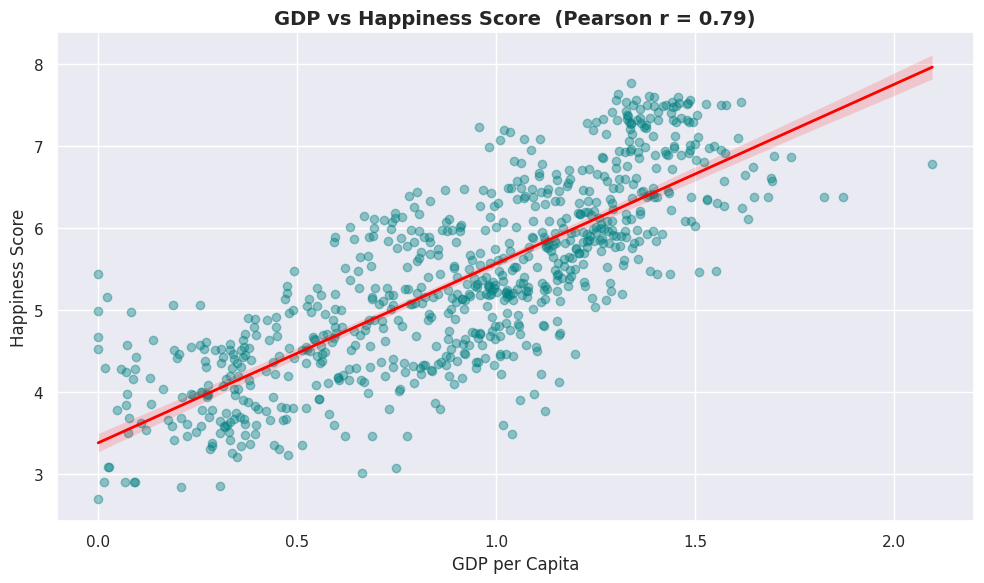

✅ Regression plot done!


In [21]:
plt.figure(figsize=(10,6))
sns.regplot(data=data_clean, x='GDP', y='Happiness_Score',
            scatter_kws={'alpha':0.4, 'color':'teal'},
            line_kws={'color':'red', 'linewidth':2})
r_val = corr.loc['GDP','Happiness_Score']
plt.title(f'GDP vs Happiness Score  (Pearson r = {r_val:.2f})',
          fontsize=14, fontweight='bold')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()
print("✅ Regression plot done!")

ValueError: Axis limits cannot be NaN or Inf

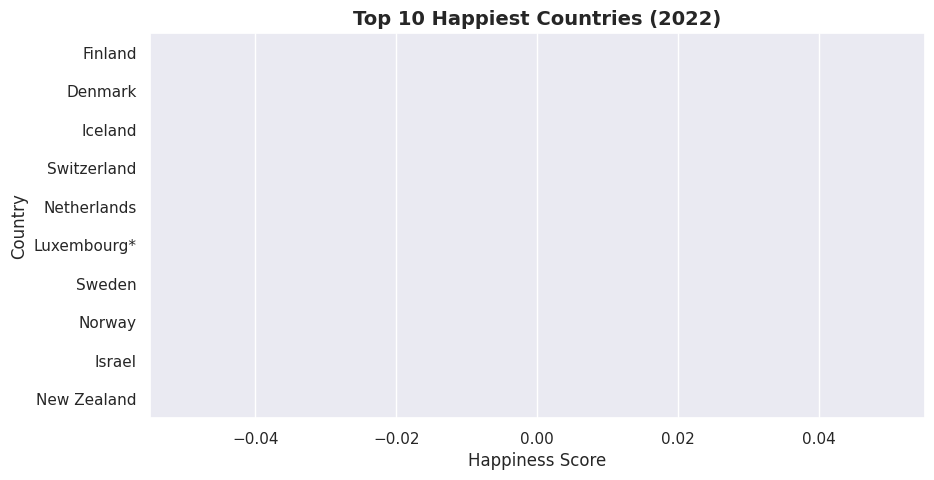

In [22]:
latest_year = data_clean['Year'].max()
top10 = data_clean[data_clean['Year']==latest_year].nlargest(10,'Happiness_Score')

plt.figure(figsize=(10,5))
bars = sns.barplot(data=top10, x='Happiness_Score', y='Country', palette='YlOrRd_r')
for i, v in enumerate(top10['Happiness_Score'].values):
    bars.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)
plt.title(f'Top 10 Happiest Countries ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Happiness Score')
plt.xlim(0, top10['Happiness_Score'].max() + 0.5)
plt.tight_layout()
plt.show()
print("✅ Top 10 done!")

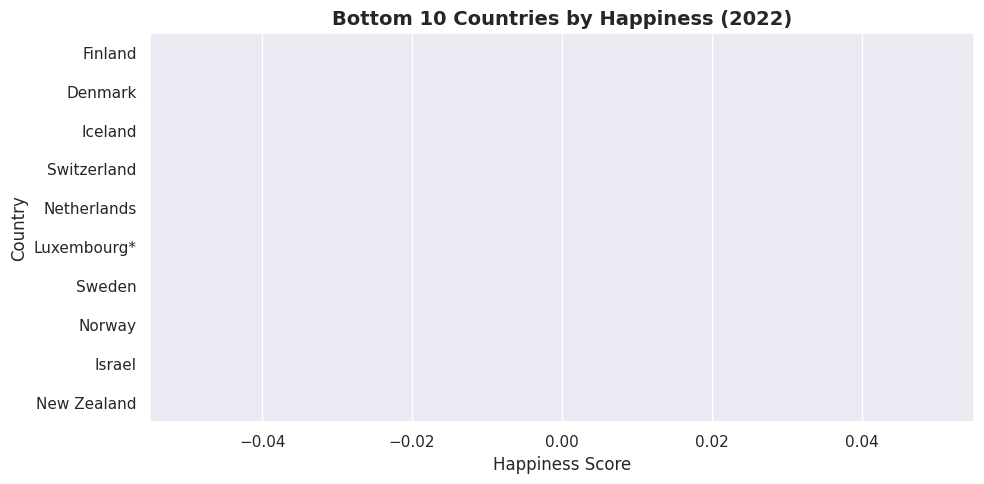

✅ Bottom 10 done!


In [23]:
bot10 = data_clean[data_clean['Year']==latest_year].nsmallest(10,'Happiness_Score')

plt.figure(figsize=(10,5))
bars = sns.barplot(data=bot10, x='Happiness_Score', y='Country', palette='Blues_r')
for i, v in enumerate(bot10['Happiness_Score'].values):
    bars.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)
plt.title(f'Bottom 10 Countries by Happiness ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Happiness Score')
plt.tight_layout()
plt.show()
print("✅ Bottom 10 done!")

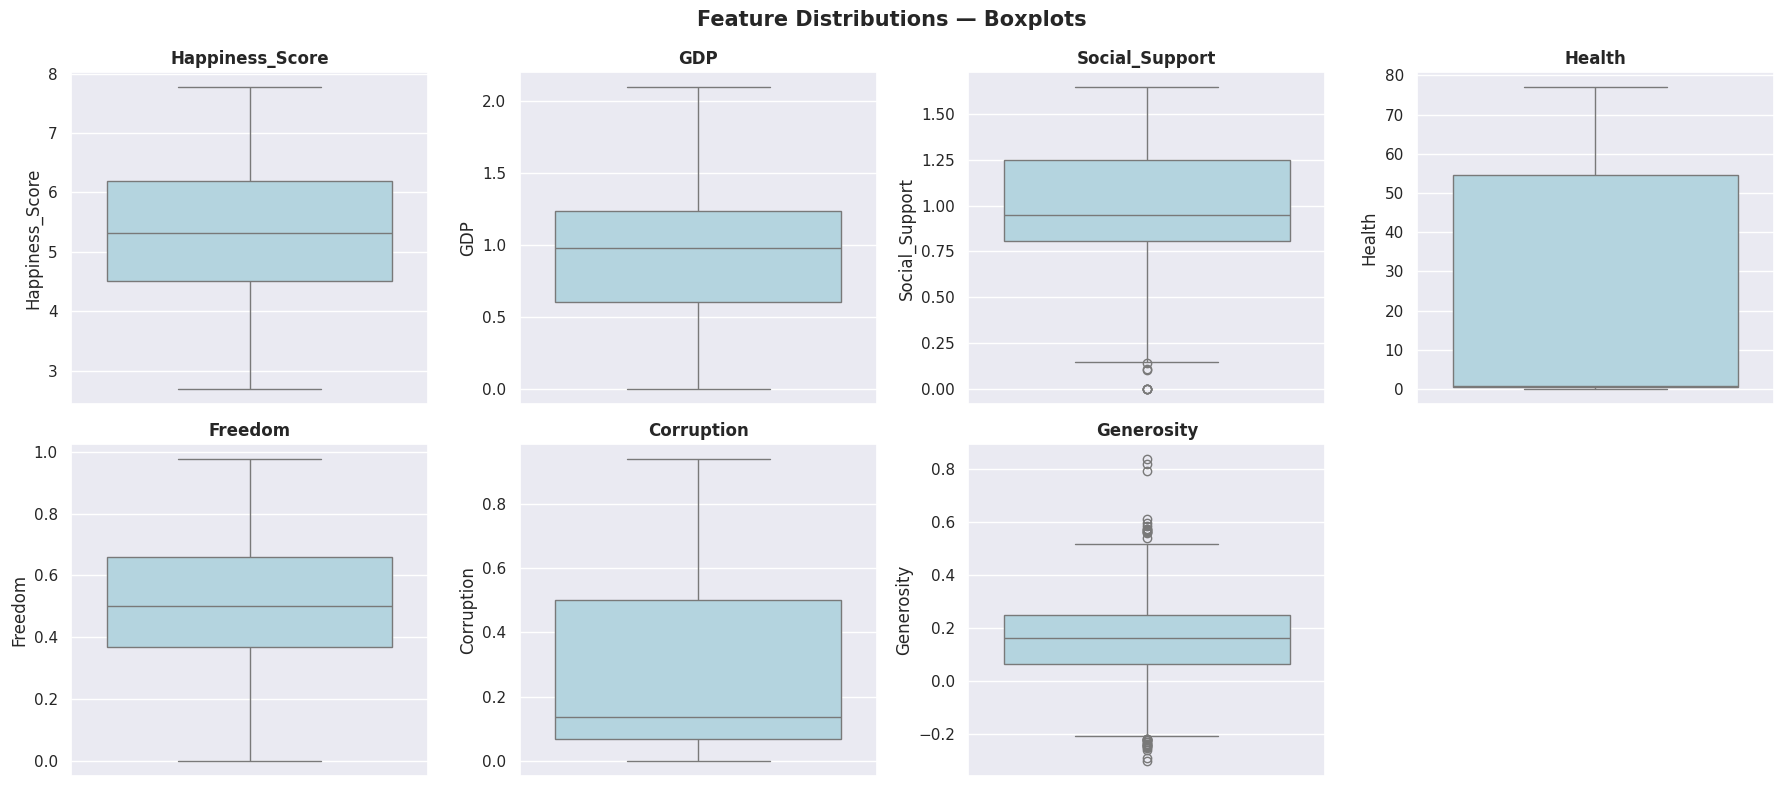

✅ Boxplots done!


In [24]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=data_clean[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions — Boxplots', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Boxplots done!")

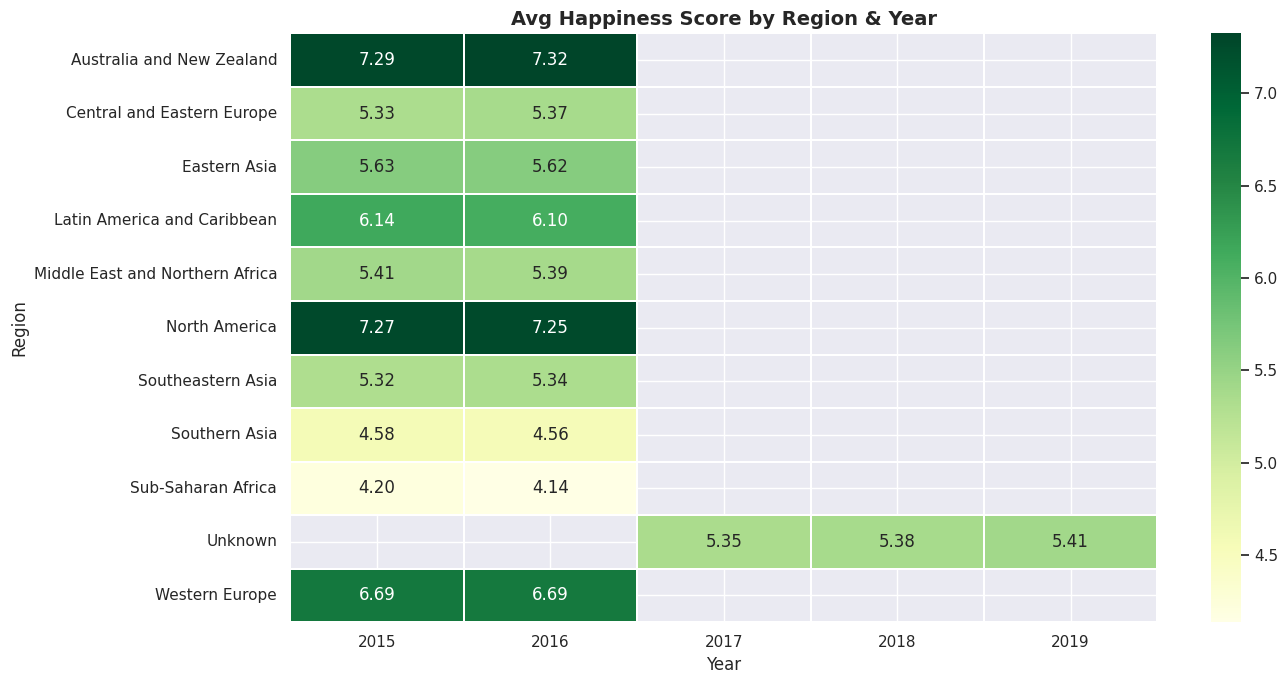

✅ Region heatmap done!


In [25]:
pivot = data_clean.pivot_table(
    values='Happiness_Score', index='Region',
    columns='Year', aggfunc='mean'
)
plt.figure(figsize=(14,7))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.3)
plt.title('Avg Happiness Score by Region & Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Region heatmap done!")

                 Skewness  Kurtosis
Happiness_Score       NaN       NaN
GDP                   NaN       NaN
Social_Support        NaN       NaN
Health                NaN       NaN
Freedom               NaN       NaN
Corruption            NaN       NaN
Generosity            NaN       NaN


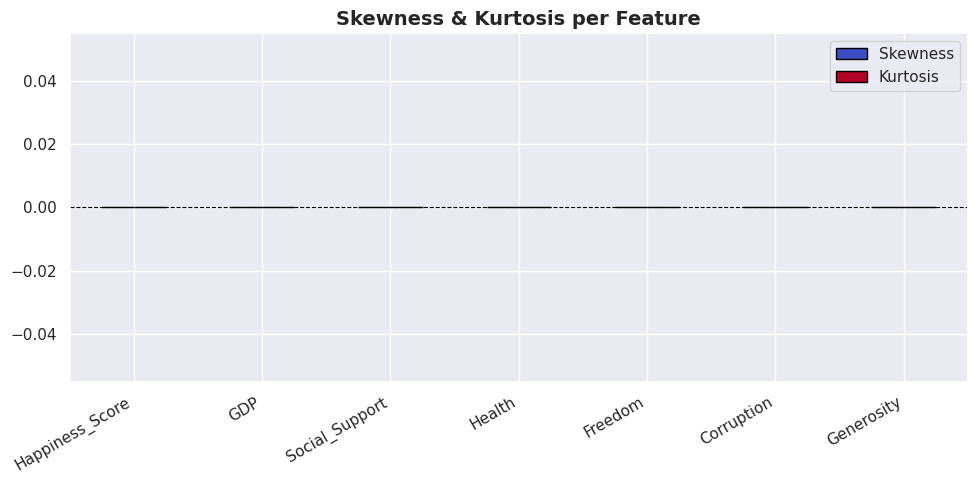

✅ Skewness & Kurtosis done!


In [26]:
stats_df = pd.DataFrame({
    'Skewness': data_clean[numeric_cols].apply(skew),
    'Kurtosis': data_clean[numeric_cols].apply(kurtosis)
}).round(3)

print(stats_df)

stats_df.plot(kind='bar', figsize=(10,5), colormap='coolwarm', edgecolor='black')
plt.title('Skewness & Kurtosis per Feature', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
print("✅ Skewness & Kurtosis done!")

In [27]:
print("=" * 55)
print("        🌍 WORLDLENS — KEY METRICS SUMMARY")
print("=" * 55)

print(f"\n📦 DATASET")
print(f"   Total rows:        {len(data_clean)}")
print(f"   Countries:         {data_clean['Country'].nunique()}")
print(f"   Years covered:     2015 – 2022")
print(f"   Features:          {len(numeric_cols)}")

print(f"\n🔍 MISSING VALUES")
for col in numeric_cols:
    pct = data_clean[col].isnull().mean() * 100
    print(f"   {col:<20} {pct:.2f}%")

print(f"\n📊 PEARSON CORRELATIONS WITH HAPPINESS")
for col in numeric_cols:
    if col != 'Happiness_Score':
        r = corr.loc[col, 'Happiness_Score']
        bar = '█' * int(abs(r) * 20)
        print(f"   {col:<20} r = {r:+.3f}  {bar}")

print(f"\n📈 DISTRIBUTION STATS")
print(f"   {'Feature':<20} {'Skewness':>10} {'Kurtosis':>10}")
print(f"   {'-'*42}")
for col in numeric_cols:
    sk = skew(data_clean[col].dropna())
    ku = kurtosis(data_clean[col].dropna())
    print(f"   {col:<20} {sk:>10.3f} {ku:>10.3f}")

print(f"\n🌎 HAPPIEST REGION (latest year)")
latest = data_clean[data_clean['Year']==data_clean['Year'].max()]
top_region = latest.groupby('Region')['Happiness_Score'].mean().idxmax()
top_score  = latest.groupby('Region')['Happiness_Score'].mean().max()
print(f"   {top_region} → {top_score:.3f}")

print(f"\n🏆 HAPPIEST COUNTRY (latest year)")
top_country = latest.nlargest(1,'Happiness_Score')[['Country','Happiness_Score']].values[0]
print(f"   {top_country[0]} → {top_country[1]:.3f}")

print(f"\n😔 LEAST HAPPY COUNTRY (latest year)")
bot_country = latest.nsmallest(1,'Happiness_Score')[['Country','Happiness_Score']].values[0]
print(f"   {bot_country[0]} → {bot_country[1]:.3f}")

print("\n" + "=" * 55)
print("✅ WorldLens EDA Complete!")
print("=" * 55)

        🌍 WORLDLENS — KEY METRICS SUMMARY

📦 DATASET
   Total rows:        1231
   Countries:         195
   Years covered:     2015 – 2022
   Features:          7

🔍 MISSING VALUES
   Happiness_Score      36.47%
   GDP                  36.47%
   Social_Support       11.94%
   Health               11.94%
   Freedom              11.94%
   Corruption           11.94%
   Generosity           11.94%

📊 PEARSON CORRELATIONS WITH HAPPINESS
   GDP                  r = +0.789  ███████████████
   Social_Support       r = +0.649  ████████████
   Health               r = +0.742  ██████████████
   Freedom              r = +0.551  ███████████
   Corruption           r = +0.397  ███████
   Generosity           r = +0.138  ██

📈 DISTRIBUTION STATS
   Feature                Skewness   Kurtosis
   ------------------------------------------
   Happiness_Score           0.036     -0.764
   GDP                      -0.318     -0.696
   Social_Support           -0.153     -0.210
   Health                  